

### 1) Import Pandas


In [1]:
import pandas as pd

### 2) Import the dataset and  Assign it to a variable called users and use the 'user_id' as index

Use the following dataset
https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user


In [2]:
users = pd.read_csv("https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user",sep="|")
users.set_index("user_id",inplace=True)
users.head()

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213


### 3) Display the first 25 entries

In [3]:
users.head(25)

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213
6,42,M,executive,98101
7,57,M,administrator,91344
8,36,M,administrator,05201
9,29,M,student,01002


### 4) Display the last 10 entries

In [4]:
users.tail(10)

,age,gender,occupation,zip_code
user_id,,,,
934,61,M,engineer,22902
935,42,M,doctor,66221
936,24,M,other,32789
937,48,M,educator,98072
938,38,F,technician,55038
939,26,F,student,33319
940,32,M,administrator,02215
941,20,M,student,97229
942,48,F,librarian,78209


### 5) What is the number of observations in the dataset?

In [17]:
print(len(users))

943


### 6) What is the number of columns in the dataset, also print the name of all the columns?

In [6]:
print(users.shape[1])
print(list(users.columns))

4
['age', 'gender', 'occupation', 'zip_code']


### 7) What is the data type of each column?

In [7]:
users.dtypes

age            int64
gender        object
occupation    object
zip_code      object
dtype: object

### 8) Print only the occupation column

In [8]:
print(users[["occupation"]].to_string(index = False))

   occupation
   technician
        other
       writer
   technician
        other
    executive
administrator
administrator
      student
       lawyer
        other
        other
     educator
    scientist
     educator
entertainment
   programmer
        other
    librarian
    homemaker
       writer
       writer
       artist
       artist
     engineer
     engineer
    librarian
       writer
   programmer
      student
       artist
      student
      student
administrator
    homemaker
      student
      student
        other
entertainment
    scientist
     engineer
administrator
    librarian
   technician
   programmer
    marketing
    marketing
administrator
      student
       writer
     educator
      student
   programmer
    executive
   programmer
    librarian
         none
   programmer
     educator
   healthcare
     engineer
administrator
    marketing
     educator
     educator
      student
      student
      student
     engineer
     engineer
    sc

### 9) How many different occupations are in this dataset?


In [9]:
users["occupation"].nunique()

21

### 10) What is the most frequent occupation?

In [10]:
users["occupation"].value_counts().idxmax()


'student'

### 11) Summarize the DataFrame.

In [11]:
users.describe(include="all")

,age,gender,occupation,zip_code
count,943.000000,943,943,943
unique,NaN,2,21,795
top,NaN,M,student,55414
freq,NaN,670,196,9
mean,34.051962,NaN,NaN,NaN
std,12.192740,NaN,NaN,NaN
min,7.000000,NaN,NaN,NaN
25%,25.000000,NaN,NaN,NaN
50%,31.000000,NaN,NaN,NaN
75%,43.000000,NaN,NaN,NaN


### 12) Summarize only the occupation column

In [12]:
users["occupation"].describe()

count         943
unique         21
top       student
freq          196
Name: occupation, dtype: object

### 13) What is the mean age of users?

In [13]:
float(users["age"].mean())

34.05196182396607

### 14) What is the age with least occurrence?

In [14]:
counts = users["age"].value_counts()
p = counts[counts == counts.min()].index.tolist()
p

[7, 66, 11, 10, 73]

### 15) What is the zip code with most occurrence?

In [15]:
int(users["zip_code"].value_counts().idxmax())


55414

### 16) Which profession has youngest people(apart from student)? Show the trend of mean age of people with profession as the seperating factor.

entertainment


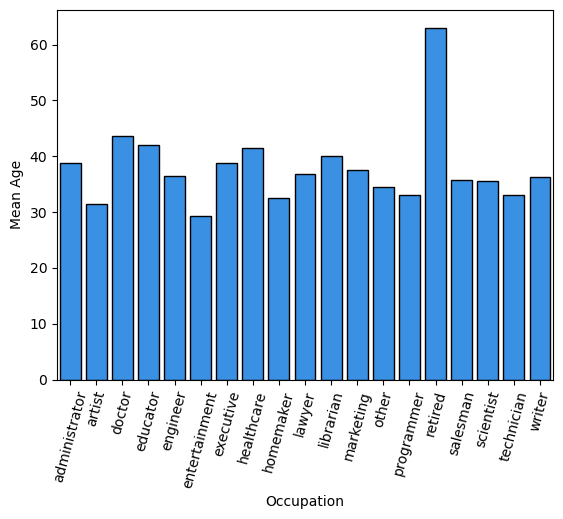

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
df = users.dropna(subset=["occupation"]).groupby("occupation")["age"].mean()
df_ns = df.drop("student")
df_ns_nn = df_ns.drop("none")
print(df_ns_nn.idxmin())

df_plot=df_ns_nn.reset_index()
df_plot_columns = ["occupation","age"]
sns.barplot(x="occupation",y="age",data=df_plot,edgecolor="black",color="dodgerblue")
plt.ylabel("Mean Age")
plt.xlabel("Occupation")
plt.xticks(rotation=75)
plt.show()